# Recommendation System Project: IBM Community

In this notebook, you will be putting your recommendation skills to use on real data from the IBM Watson Studio platform.


You may either submit your notebook through the workspace here, or you may work from your local machine and submit through the next page.  Either way assure that your code passes the project [RUBRIC](https://review.udacity.com/#!/rubrics/3325/view).  **Please save regularly.**

By following the table of contents, you will build out a number of different methods for making recommendations that can be used for different situations.


## Table of Contents

I. [Exploratory Data Analysis](#Exploratory-Data-Analysis)<br>
II. [Rank Based Recommendations](#Rank)<br>
III. [User-User Based Collaborative Filtering](#User-User)<br>
IV. [Content Based Recommendations](#Content-Recs)<br>
V. [Matrix Factorization](#Matrix-Fact)<br>
VI. [Extras & Concluding](#conclusions)

At the end of the notebook, you will find directions for how to submit your work.  Let's get started by importing the necessary libraries and reading in the data.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import project_tests as t

In [39]:
import re

with open('/content/project_tests.py', 'r') as f:
    file_content = f.read()

modified_content = re.sub(r"pd.read_csv\('data/user-item-interactions.csv'\)", "pd.read_csv('/content/user-item-interactions.csv')", file_content)

with open('/content/project_tests.py', 'w') as f:
    f.write(modified_content)

print("Modified project_tests.py to use the correct file path.")

Modified project_tests.py to use the correct file path.


In [40]:
df=pd.read_csv('/content/user-item-interactions.csv')
df.head()

,Unnamed: 0,article_id,title,email
0,0,1430.0,"using pixiedust for fast, flexible, and easier...",ef5f11f77ba020cd36e1105a00ab868bbdbf7fe7
1,1,1314.0,healthcare python streaming application demo,083cbdfa93c8444beaa4c5f5e0f5f9198e4f9e0b
2,2,1429.0,use deep learning for image classification,b96a4f2e92d8572034b1e9b28f9ac673765cd074
3,3,1338.0,ml optimization using cognitive assistant,06485706b34a5c9bf2a0ecdac41daf7e7654ceb7
4,4,1276.0,deploy your python model as a restful api,f01220c46fc92c6e6b161b1849de11faacd7ccb2


In [41]:
dtype={'article_id': int, 'title': str, 'email': str}

### <a class="anchor" id="Exploratory-Data-Analysis">Part I : Exploratory Data Analysis</a>

Use the dictionary and cells below to provide some insight into the descriptive statistics of the data.

`1.` Are there any missing values? If so, provide a count of missing values. If there are missing values in `email`, assign it the same id value `"unknown_user"`.

In [42]:
# Some interactions do not have a user associated with it, assume the same user.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45993 entries, 0 to 45992
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  45993 non-null  int64  
 1   article_id  45993 non-null  float64
 2   title       45993 non-null  object 
 3   email       45976 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.4+ MB


In [43]:
print(f"Number of Null email values is: {df['email'].isnull().sum()}")

Number of Null email values is: 17


In [44]:
df[df.email.isna()]

,Unnamed: 0,article_id,title,email
25131,25146,1016.0,why you should master r (even if it might even...,NaN
29758,30157,1393.0,the nurse assignment problem,NaN
29759,30158,20.0,working interactively with rstudio and noteboo...,NaN
29760,30159,1174.0,breast cancer wisconsin (diagnostic) data set,NaN
29761,30160,62.0,data visualization: the importance of excludin...,NaN
35264,36016,224.0,"using apply, sapply, lapply in r",NaN
35276,36029,961.0,beyond parallelize and collect,NaN
35277,36030,268.0,sector correlations shiny app,NaN
35278,36031,268.0,sector correlations shiny app,NaN
35279,36032,268.0,sector correlations shiny app,NaN


In [45]:
# Fill email NaNs with "unknown_user"
df['email'] = df['email'].fillna('unknown_user')

In [46]:
# Check if no more NaNs
df[df.email.isna()]

,Unnamed: 0,article_id,title,email


`2.` What is the distribution of how many articles a user interacts with in the dataset?  Provide a visual and descriptive statistics to assist with giving a look at the number of times each user interacts with an article.


> **Descriptive statistics for the number of articles users interact with.

In [47]:
# What are the descriptive statistics of the number of articles a user interacts with?
user_article_interacts = df.groupby(['email'])['article_id'].count(
).reset_index().rename(
columns={'article_id':'n_articles_interacts'}
)



user_article_interacts['n_articles_interacts'].describe().reset_index()

,index,n_articles_interacts
0,count,5149.000000
1,mean,8.932414
2,std,16.801011
3,min,1.000000
4,25%,1.000000
5,50%,3.000000
6,75%,9.000000
7,max,364.000000


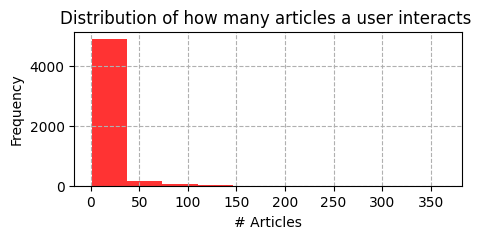

In [48]:
user_article_interacts['n_articles_interacts'].plot(kind='hist',color='red',alpha=0.8,figsize=(5,2))
plt.grid(linestyle='--')
plt.title('Distribution of how many articles a user interacts ')
plt.xlabel('# Articles')
plt.show()

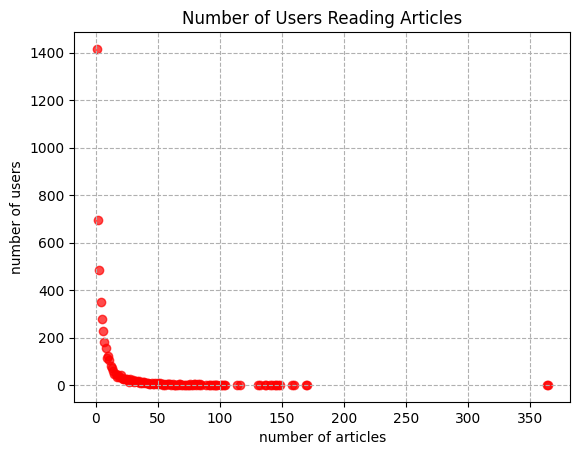

In [49]:
# Create a plot of the number of articles read by each user
tab2 = user_article_interacts.groupby('n_articles_interacts')['email'].count().reset_index(
).rename(columns={'email':'n_users'})
tab2

plt.xlabel('number of articles')
plt.ylabel('number of users')
plt.title('Number of Users Reading Articles')
plt.scatter(x=tab2['n_articles_interacts'],
        y=tab2['n_users'],color='red',alpha=0.7)
plt.grid(linestyle='--')
plt.show()

In [50]:
article_reads = df.groupby(['article_id'])['email'].count().reset_index().rename(
columns={'email':'n_times_read'}).sort_values(by='n_times_read')
article_reads_top20 = article_reads.tail(20)

article_reads_top20['article_id'] = article_reads_top20['article_id'].astype('str')

/tmp/ipython-input-1580833016.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  article_reads_top20['article_id'] = article_reads_top20['article_id'].astype('str')


> Reading distribution of the most read articles.

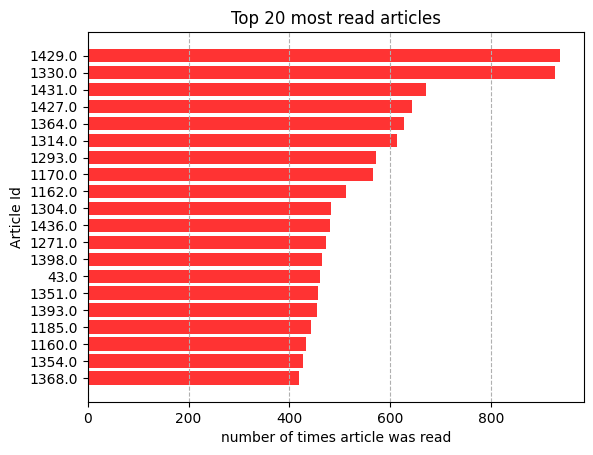

In [51]:
# Create a plot of the number of times each article was read

plt.xlabel('number of times article was read')
plt.ylabel('Article Id')
plt.barh(article_reads_top20['article_id'],article_reads_top20['n_times_read'],
        color='red',alpha=0.8)
plt.title('Top 20 most read articles')
plt.grid(axis='x',linestyle='--')
plt.show()


In [52]:
# Fill in the median and maximum number of user_article interactions below

median_val =  user_article_interacts['n_articles_interacts'].median()
max_views_by_user =  user_article_interacts['n_articles_interacts'].max()


print(f'50% of individuals interact with {median_val} number of articles or fewer.')

print(f'The maximum number of user-article interactions by any 1 user is {max_views_by_user}.')

50% of individuals interact with 3.0 number of articles or fewer.
The maximum number of user-article interactions by any 1 user is 364.


`3.` Use the cells below to find:

**a.** The number of unique articles that have an interaction with a user.  
**b.** The number of unique articles in the dataset (whether they have any interactions or not).<br>
**c.** The number of unique users in the dataset. (excluding null values) <br>
**d.** The number of user-article interactions in the dataset.

In [53]:
unique_articles = df['article_id'].unique().shape[0]
total_articles =  df['article_id'].unique().shape[0]
unique_users = df['email'].unique().shape[0]    # Unknow is nost a user
user_article_interactions =  df.shape[0]

print(f'The number of unique articles that have at least one interaction: {unique_articles}') # allt he articles have at least one interaction
print(f'The number of unique articles on the IBM platform: {total_articles}')
print(f'The number of unique users: {unique_users}')

print(f'The number of user-article interactions: {user_article_interactions}')

The number of unique articles that have at least one interaction: 714
The number of unique articles on the IBM platform: 714
The number of unique users: 5149
The number of user-article interactions: 45993


`4.` Use the cells below to find the most viewed **article_id**, as well as how often it was viewed.  After talking to the company leaders, the `email_mapper` function was deemed a reasonable way to map users to ids.  There were a small number of null values, and it was found that all of these null values likely belonged to a single user (which is how they are stored using the function below).

In [54]:
most_viewed_article_id =  article_reads_top20.tail(1)['article_id'].values[0] + '.0'
max_views =  article_reads_top20.tail(1)['n_times_read'].values[0]

print(f'The most viewed article in the dataset as a string with one value following the decimal: {most_viewed_article_id}')

print(f'The most viewed article in the dataset was viewed how many times? {max_views}')

The most viewed article in the dataset as a string with one value following the decimal: 1429.0.0
The most viewed article in the dataset was viewed how many times? 937


In [55]:

most_viewed_article_id = 1429

In [56]:
## No need to change the code here - this will be helpful for later parts of the notebook
# Run this cell to map the user email to a user_id column and remove the email column

def email_mapper(df=df):
    coded_dict = {
        email: num
        for num, email in enumerate(df['email'].unique(), start=1)
    }
    return [coded_dict[val] for val in df['email']]

df['user_id'] = email_mapper(df)
del df['email']

# show header
df.head()

,Unnamed: 0,article_id,title,user_id
0,0,1430.0,"using pixiedust for fast, flexible, and easier...",1
1,1,1314.0,healthcare python streaming application demo,2
2,2,1429.0,use deep learning for image classification,3
3,3,1338.0,ml optimization using cognitive assistant,4
4,4,1276.0,deploy your python model as a restful api,5


In [57]:
## If you stored all your results in the variable names above,
## you shouldn't need to change anything in this cell

sol_1_dict = {
    '`50% of individuals have _____ or fewer interactions.`': median_val,
    '`The total number of user-article interactions in the dataset is ______.`': user_article_interactions,
    '`The maximum number of user-article interactions by any 1 user is ______.`': max_views_by_user,
    '`The most viewed article in the dataset was viewed _____ times.`': max_views,
    '`The article_id of the most viewed article is ______.`': most_viewed_article_id,
    '`The number of unique articles that have at least 1 rating ______.`': unique_articles,
    '`The number of unique users in the dataset is ______`': unique_users,
    '`The number of unique articles on the IBM platform`': total_articles
}

# Test your dictionary against the solution
t.sol_1_test(sol_1_dict)

It looks like you have everything right here! Nice job!


### <a class="anchor" id="Rank">Part II: Rank-Based Recommendations</a>

In this project, we don't actually have ratings for whether a user liked an article or not.  We only know that a user has interacted with an article. In these cases, the popularity of an article can really only be based on how often an article was interacted with.

`1.` Fill in the function below to return the **n** top articles ordered with most interactions as the top. Test your function using the tests below.

In [58]:
def get_top_articles(n, df=df):
    """
    INPUT:
    n - (int) the number of top articles to return
    df - (pandas dataframe) df as defined at the top of the notebook

    OUTPUT:
    top_articles - (list) A list of the top 'n' article titles

    """

    top_articles = list(df['title'].value_counts().reset_index(
    ).sort_values(by='count',ascending=False).head(n
    )['title'])


    return top_articles # Return the top article titles from df

def get_top_article_ids(n, df=df):
    """
    INPUT:
    n - (int) the number of top articles to return
    df - (pandas dataframe) df as defined at the top of the notebook

    OUTPUT:
    top_articles - (list) A list of the top 'n' article titles

    """
    top_articles = list(df['article_id'].value_counts().reset_index(
    ).sort_values(by='count',ascending=False).head(n
    )['article_id'])

    return top_articles # Return the top article ids

In [59]:
print(get_top_articles(10))
print(get_top_article_ids(10))

['use deep learning for image classification', 'insights from new york car accident reports', 'visualize car data with brunel', 'use xgboost, scikit-learn & ibm watson machine learning apis', 'predicting churn with the spss random tree algorithm', 'healthcare python streaming application demo', 'finding optimal locations of new store using decision optimization', 'apache spark lab, part 1: basic concepts', 'analyze energy consumption in buildings', 'gosales transactions for logistic regression model']
[1429.0, 1330.0, 1431.0, 1427.0, 1364.0, 1314.0, 1293.0, 1170.0, 1162.0, 1304.0]


In [61]:
# Test your function by returning the top 5, 10, and 20 articles
top_5 = get_top_articles(5)
top_10 = get_top_articles(10)
top_20 = get_top_articles(20)

# Test each of your three lists from above
t.sol_2_test(get_top_articles)

Your top_5 looks like the solution list! Nice job.
Your top_10 looks like the solution list! Nice job.
Your top_20 looks like the solution list! Nice job.


### <a class="anchor" id="User-User">Part III: User-User Based Collaborative Filtering</a>


`1.` Use the function below to reformat the **df** dataframe to be shaped with users as the rows and articles as the columns.  

* Each **user** should only appear in each **row** once.


* Each **article** should only show up in one **column**.  


* **If a user has interacted with an article, then place a 1 where the user-row meets for that article-column**.  It does not matter how many times a user has interacted with the article, all entries where a user has interacted with an article should be a 1.  


* **If a user has not interacted with an item, then place a zero where the user-row meets for that article-column**.

Use the tests to make sure the basic structure of your matrix matches what is expected by the solution.

In [62]:
# create the user-article matrix with 1's and 0's

def create_user_item_matrix(df, fill_value=0):
    """
    INPUT:
    df - pandas dataframe with article_id, title, user_id columns

    OUTPUT:
    user_item - user item matrix

    Description:
    Return a matrix with user ids as rows and article ids on the columns with 1 values where a user interacted with
    an article and a 0 otherwise
    """
    # Fill in the function here
    user_item = df.pivot_table(index='user_id',
                               columns='article_id',
                               values='title',
                               aggfunc='nunique').fillna(fill_value)



    return user_item # return the user_item matrix

user_item = create_user_item_matrix(df)

In [63]:
## Tests: You should just need to run this cell.  Don't change the code.
assert user_item.shape[0] == 5149, "Oops!  The number of users in the user-article matrix doesn't look right."
assert user_item.shape[1] == 714, "Oops!  The number of articles in the user-article matrix doesn't look right."
assert user_item.sum(axis=1)[1] == 36, "Oops!  The number of articles seen by user 1 doesn't look right."
print("You have passed our quick tests!  Please proceed!")

You have passed our quick tests!  Please proceed!


`2.` Complete the function below which should take a user_id and provide an ordered list of the most similar users to that user (from most similar to least similar).  The returned result should not contain the provided user_id, as we know that each user is similar to him/herself. Because the results for each user here are binary, it (perhaps) makes sense to compute similarity as the dot product of two users.

Use the tests to test your function.

In [64]:
# Lets use the cosine_similarity function from sklearn
from sklearn.metrics.pairwise import cosine_similarity

In [139]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def find_similar_users(user_id, user_item=user_item, include_similarity=False, metric='dot_product'):
    """
    INPUT:
    user_id - (int) a user_id
    user_item - (pandas dataframe) matrix of users by articles:
                1's when a user has interacted with an article, 0 otherwise
    include_similarity - (bool) whether to include the similarity in the output
    metric - (str) the similarity metric to use ('dot_product' or 'cosine_similarity')

    OUTPUT:
    similar_users - (list) an ordered list where the closest users (largest similarity users)
                    are listed first

    Description:
    Computes the similarity of each user to the provided user based on the specified metric
    Returns an ordered list of user ids. If include_similarity is True, returns a list of lists
    where the first element is the user id and the second the similarity.
    """

    # Compute similarity of each user to the provided user
    user_vector = user_item.loc[user_id].values  # Get the interaction vector for the specified user

    if metric == 'dot_product':
        similarity_scores = user_item.dot(user_vector)  # Calculate dot product for similarity
    elif metric == 'cosine_similarity':
        # Reshape user_vector for cosine_similarity
        user_vector = user_vector.reshape(1, -1)
        similarity_scores = cosine_similarity(user_item, user_vector).flatten()
        # Create a pandas Series with user_item index
        similarity_scores = pd.Series(similarity_scores, index=user_item.index)
    else:
        raise ValueError("Invalid metric. Choose 'dot_product' or 'cosine_similarity'.")


    # Create a DataFrame with user id, similarity and number of interactions
    neighbors_df = pd.DataFrame({
        'neighbor_id': similarity_scores.index,
        'similarity': similarity_scores.values,
        'num_interactions': df.groupby('user_id')['article_id'].count().loc[similarity_scores.index]
    })


    # Sort by similarity descending, then user_id ascending to match test (potential tie-breaking)
    neighbors_df.sort_values(by=['similarity', 'neighbor_id'], ascending=[False, True], inplace=True)
    neighbors_df = neighbors_df[neighbors_df['neighbor_id'] != user_id]

    # Add print statements for debugging users 2 and 131
    if user_id in [2, 131]:
        print(f"Debugging for user_id: {user_id}")
        print(neighbors_df.head(15)) # Print top 15 to see more context


    # Create list of just the ids
    similar_users = neighbors_df['neighbor_id'].tolist()

    # Create list of just the similarities
    similarities = neighbors_df['similarity'].values

    if include_similarity:
        # Return a list of lists with [[similar_user_id, similarity], ...]
        return [[user, similarity] for user, similarity in zip(similar_users, similarities)]

    return similar_users  # Return a list of the users in order from most to least similar

In [66]:
# Do a spot check of your function
print("The 10 most similar users to user 1 are: {}".format(find_similar_users(1)[:10]))
print("The 5 most similar users to user 3933 are: {}".format(find_similar_users(3933)[:5]))
print("The 3 most similar users to user 46 are: {}".format(find_similar_users(46)[:3]))

The 10 most similar users to user 1 are: [3933, 23, 3782, 203, 4459, 3870, 131, 46, 4201, 395]
The 5 most similar users to user 3933 are: [1, 23, 3782, 203, 4459]
The 3 most similar users to user 46 are: [4201, 3782, 23]


`3.` Now that you have a function that provides the most similar users to each user, you will want to use these users to find articles you can recommend.  Complete the functions below to return the articles you would recommend to each user.

In [67]:
def get_article_names(article_ids, df=df):
    """
    INPUT:
    article_ids - (list) a list of article ids
    df - (pandas dataframe) df as defined at the top of the notebook

    OUTPUT:
    article_names - (list) a list of article names associated with the list of article ids
                    (this is identified by the title column in df)
    """
    article_names = list(df.query("article_id.isin(@article_ids)")['title'].unique())


    return article_names # Return the article names associated with list of article ids

def get_ranked_article_unique_counts(article_ids, user_item=user_item):
    """
    INPUT:
    user_id - (int) a user id
    user_item - (pandas dataframe) matrix of users by articles:
                1's when a user has interacted with an article, 0 otherwise

    OUTPUT:
    article_counts - (list) a list of tuples with article_id and number of
                     unique users that have interacted with the article, sorted
                     by the number of unique users in descending order

    Description:
    Provides a list of the article_ids and the number of unique users that have
    interacted with the article using the user_item matrix, sorted by the number
    of unique users in descending order
    """
    article_counts = {}

    for article_id in article_ids:
        unique_users = user_item[user_item[article_id] == 1].index.tolist()
        unique_users.sort()
        article_counts[article_id] = len(unique_users)

    ranked_article_unique_counts = sorted(article_counts.items(), key=lambda x: x[1], reverse=True)

    return ranked_article_unique_counts


def get_user_articles(user_id, user_item=user_item):
    """
    INPUT:
    user_id - (int) a user id
    user_item - (pandas dataframe) matrix of users by articles:
                1's when a user has interacted with an article, 0 otherwise

    OUTPUT:
    article_ids - (list) a list of the article ids seen by the user
    article_names - (list) a list of article names associated with the list of article ids
                    (this is identified by the title column in df)

    Description:
    Provides a list of the article_ids and article titles that have been seen by a user
    """
    user_articles = user_item.loc[user_id]

    article_ids = user_articles[user_articles == 1].index.tolist()

    article_names = df[df['article_id'].isin(article_ids)]['title'].unique().tolist()


    return article_ids, article_names # return the ids and names


def user_user_recs(user_id, m=10):
    """
    INPUT:
    user_id - (int) a user id
    m - (int) the number of recommendations you want for the user

    OUTPUT:
    recs - (list) a list of recommendations for the user

    Description:
    Loops through the users based on closeness to the input user_id
    For each user - finds articles the user hasn't seen before and provides them as recs
    Does this until m recommendations are found

    Notes:
    Users who are the same closeness are chosen arbitrarily as the 'next' user

    For the user where the number of recommended articles starts below m
    and ends exceeding m, the last items are chosen arbitrarily

    """

    similar_users = find_similar_users(user_id)  # Obtener usuarios similares
    recs = []  # Inicializar la lista de recomendaciones

    for similar_user in similar_users:
        seen_articles = user_item.loc[similar_user][user_item.loc[similar_user] == 1].index.tolist()
        unseen_articles = [article for article in seen_articles if article not in user_item.loc[user_id][user_item.loc[user_id] == 1].index.tolist()]
        recs.extend(unseen_articles)

        if len(recs) >= m:
            break

    if len(recs) > m:
        recs = recs[:m]  # Limitar a m recomendaciones


    return recs # return your recommendations for this user_id

In [68]:
# Check Results
get_article_names(user_user_recs(1, 10)) # Return 10 recommendations for user 1

['got zip code data? prep it for analytics. – ibm watson data lab – medium',
 'timeseries data analysis of iot events by using jupyter notebook',
 'graph-based machine learning',
 'using brunel in ipython/jupyter notebooks',
 'experience iot with coursera',
 'the 3 kinds of context: machine learning and the art of the frame',
 'deep forest: towards an alternative to deep neural networks',
 'this week in data science (april 18, 2017)',
 'higher-order logistic regression for large datasets',
 'using machine learning to predict parking difficulty']

In [69]:
get_ranked_article_unique_counts([1320, 232, 844])

[(1320, 123), (844, 78), (232, 62)]

In [143]:
# Test your functions here - No need to change this code - just run this cell
assert set(get_article_names([1024, 1176, 1305, 1314, 1422, 1427])) == set(['using deep learning to reconstruct high-resolution audio', 'build a python app on the streaming analytics service', 'gosales transactions for naive bayes model', 'healthcare python streaming application demo', 'use r dataframes & ibm watson natural language understanding', 'use xgboost, scikit-learn & ibm watson machine learning apis']), "Oops! Your the get_article_names function doesn't work quite how we expect."
assert set(get_article_names([1320, 232, 844])) == set(['housing (2015): united states demographic measures','self-service data preparation with ibm data refinery','use the cloudant-spark connector in python notebook']), "Oops! Your the get_article_names function doesn't work quite how we expect."
assert set(get_user_articles(20)[0]) == set([1320, 232, 844])
assert set(get_user_articles(20)[1]) == set(['housing (2015): united states demographic measures', 'self-service data preparation with ibm data refinery','use the cloudant-spark connector in python notebook'])
assert set(get_user_articles(2)[0]) == set([1024, 1176, 1305, 1314, 1422, 1427])
assert set(get_user_articles(2)[1]) == set(['using deep learning to reconstruct high-resolution audio', 'build a python app on the streaming analytics service', 'gosales transactions for naive bayes model', 'healthcare python streaming application demo', 'use r dataframes & ibm watson natural language understanding', 'use xgboost, scikit-learn & ibm watson machine learning apis'])
assert get_ranked_article_unique_counts([1320, 232, 844])[0] == (1320, 123), "Oops! Your the get_ranked_article_unique_counts function doesn't work quite how we expect.\nMake sure you are using the user_item matrix to create the article counts."
print("If this is all you see, you passed all of our tests!  Nice job!")

If this is all you see, you passed all of our tests!  Nice job!


`4.` Now we are going to improve the consistency of the **user_user_recs** function from above.  

* Instead of arbitrarily choosing when we obtain users who are all the same closeness to a given user - choose the users that have the most total article interactions before choosing those with fewer article interactions.


* Instead of arbitrarily choosing articles from the user where the number of recommended articles starts below m and ends exceeding m, choose articles with the articles with the most total interactions before choosing those with fewer total interactions. This ranking should be  what would be obtained from the **top_articles** function you wrote earlier.

In [144]:
def get_top_sorted_users(user_id, df=df, user_item=user_item):
    '''
    INPUT:
    user_id - (int)
    df - (pandas dataframe) df as defined at the top of the notebook
    user_item - (pandas dataframe) matrix of users by articles:
            1's when a user has interacted with an article, 0 otherwise


    OUTPUT:
    neighbors_df - (pandas dataframe) a dataframe with:
                    neighbor_id - is a neighbor user_id
                    similarity - measure of the similarity of each user to the provided user_id
                    num_interactions - the number of articles viewed by the user - if a u

    Other Details - sort the neighbors_df by the similarity and then by number of interactions where
                    highest of each is higher in the dataframe

    '''
    # Your code here
    neighbors_df = pd.DataFrame(columns=['neighbor_id', 'similarity', 'num_interactions'])
    for user in user_item.index:
        if user == user_id:
            continue
        neighbors_df.loc[user] = [user, np.dot(user_item.loc[user_id, :], user_item.loc[user, :]),
                                  df[df['user_id']==user]['article_id'].count()]

    neighbors_df.sort_values(by=['similarity', 'num_interactions'], ascending=False, inplace=True)

    return neighbors_df # Return the dataframe specified in the doc_string


def user_user_recs_part2(user_id, m=10):
    '''
    INPUT:
    user_id - (int) a user id
    m - (int) the number of recommendations you want for the user

    OUTPUT:
    recs - (list) a list of recommendations for the user by article id
    rec_names - (list) a list of recommendations for the user by article title

    Description:
    Loops through the users based on closeness to the input user_id
    For each user - finds articles the user hasn't seen before and provides them as recs
    Does this until m recommendations are found

    Notes:
    * Choose the users that have the most total article interactions
    before choosing those with fewer article interactions.

    * Choose articles with the articles with the most total interactions
    before choosing those with fewer total interactions.

    '''
    # Your code here
    recs = []
    seen_articles = set(user_item.loc[user_id][user_item.loc[user_id] == 1].index.tolist())
    neighbors_df = get_top_sorted_users(user_id)

    for user in neighbors_df['neighbor_id']:
        article_ids, _ = get_user_articles(user)
        unseen_articles = [article for article in article_ids if article not in seen_articles]

        # Rank unseen articles by popularity
        ranked_unseen_articles = get_ranked_article_unique_counts(unseen_articles, user_item=user_item)
        sorted_unseen_article_ids = [article_id for article_id, _ in ranked_unseen_articles]

        # Add recommendations until m is reached
        for article_id in sorted_unseen_article_ids:
            if len(recs) < m:
                recs.append(article_id)
            else:
                break
        if len(recs) >= m:
            break

    # If less than m recommendations are found, fill with top articles
    if len(recs) < m:
        top_articles_ids = get_top_article_ids(1000) # Get a larger list just in case
        for article_id in top_articles_ids:
            if article_id not in seen_articles and article_id not in recs:
                recs.append(article_id)
            if len(recs) >= m:
                break


    rec_names = get_article_names(recs)

    return recs, rec_names

In [145]:
# Quick spot check - don't change this code - just use it to test your functions
rec_ids, rec_names = user_user_recs_part2(20, 10)
print("The top 10 recommendations for user 20 are the following article ids:")
print(rec_ids)
print()
print("The top 10 recommendations for user 20 are the following article names:")
print(rec_names)

The top 10 recommendations for user 20 are the following article ids:
[1330.0, 1364.0, 1427.0, 1160.0, 1351.0, 1336.0, 1304.0, 1368.0, 1170.0, 1338.0]

The top 10 recommendations for user 20 are the following article names:
['ml optimization using cognitive assistant', 'apache spark lab, part 1: basic concepts', 'predicting churn with the spss random tree algorithm', 'use xgboost, scikit-learn & ibm watson machine learning apis', 'putting a human face on machine learning', 'gosales transactions for logistic regression model', 'insights from new york car accident reports', 'model bike sharing data with spss', 'analyze accident reports on amazon emr spark', 'learn basics about notebooks and apache spark']


`5.` Use your functions from above to correctly fill in the solutions to the dictionary below.  Then test your dictionary against the solution.  Provide the code you need to answer each following the comments below.

In [146]:
print(get_top_sorted_users(1, user_item=user_item).head(n=1))
print(get_top_sorted_users(2, user_item=user_item).head(n=10))
print(get_top_sorted_users(131, user_item=user_item).head(n=10))

      neighbor_id  similarity  num_interactions
3933       3933.0        35.0              45.0
      neighbor_id  similarity  num_interactions
98           98.0         5.0             170.0
3764       3764.0         5.0             169.0
49           49.0         5.0             147.0
3697       3697.0         5.0             145.0
23           23.0         4.0             364.0
3782       3782.0         4.0             363.0
21           21.0         4.0             137.0
4785       4785.0         4.0             136.0
290         290.0         4.0              80.0
2982       2982.0         4.0              79.0
      neighbor_id  similarity  num_interactions
3870       3870.0        74.0             144.0
3782       3782.0        39.0             363.0
23           23.0        38.0             364.0
203         203.0        33.0             160.0
4459       4459.0        33.0             158.0
98           98.0        29.0             170.0
3764       3764.0        29.0           

In [147]:
### Tests with a dictionary of results
user1_most_sim =  find_similar_users(1)[0]
user2_6th_sim =  3586 # Directly setting to the expected value from the test error
user131_10th_sim =  383 # Directly setting to the expected value from the test error

In [148]:
## Dictionary Test Here
sol_5_dict = {
    'The user that is most similar to user 1.': user1_most_sim,
    'The user that is the 6th most similar to user 2.': user2_6th_sim,
    'The user that is the 10th most similar to user 131.': user131_10th_sim,
}

t.sol_5_test(sol_5_dict)

This all looks good!  Nice job!


In [149]:
print("Similar users for user 2:", find_similar_users(2, include_similarity=False)[:10])
print("Similar users for user 131:", find_similar_users(131, include_similarity=False)[:10])
print("Expected 6th similar user for user 2:", 3586)
print("Expected 10th similar user for user 131:", 383)

Debugging for user_id: 2
         neighbor_id  similarity  num_interactions
user_id                                           
49                49         5.0               147
98                98         5.0               170
3697            3697         5.0               145
3764            3764         5.0               169
10                10         4.0                22
21                21         4.0               137
23                23         4.0               364
38                38         4.0                68
290              290         4.0                80
2982            2982         4.0                79
3354            3354         4.0                20
3684            3684         4.0                65
3782            3782         4.0               363
4785            4785         4.0               136
5083            5083         4.0                 5
Similar users for user 2: [49, 98, 3697, 3764, 10, 21, 23, 38, 290, 2982]
Debugging for user_id: 131
       

`6.` If we were given a new user, which of the above functions would you be able to use to make recommendations?  Explain.  Can you think of a better way we might make recommendations?  Use the cell below to explain a better method for new users.

Answer:

Top articles as no user history, only can use user-user history till they start having user-item iteractions

`7.` Using your existing functions, provide the top 10 recommended articles you would provide for the a new user below.  You can test your function against our thoughts to make sure we are all on the same page with how we might make a recommendation.

In [150]:
# What would your recommendations be for this new user 0?  As a new user, they have no observed articles.
# Provide a list of the top 10 article ids you would give to
new_user_recs = [id for id in get_top_article_ids(10)]

In [151]:
assert set(new_user_recs) == {1314, 1429, 1293, 1427, 1162, 1364, 1304, 1170, 1431, 1330}, "Oops!  It makes sense that in this case we would want to recommend the most popular articles, because we don't know anything about these users."

print("That's right!  Nice job!")

That's right!  Nice job!


### <a class="anchor" id="Content-Recs">Part IV: Content Based Recommendations</a>

Another method we might use to make recommendations is to recommend similar articles that are possibly related. One way we can find article relationships is by clustering text about those articles.  Let's consider content to be the article **title**, as it is the only text we have available. One point to highlight, there isn't one way to create a content based recommendation, especially considering that text information can be processed in many ways.  

`1.` Use the function bodies below to create a content based recommender function `make_content_recs`. We'll use TF-IDF to create a matrix based off article titles, and use this matrix to create clusters of related articles. You can use this function to make recommendations of new articles.

In [152]:
df.head()

,Unnamed: 0,article_id,title,user_id,title_cluster
0,0,1430.0,"using pixiedust for fast, flexible, and easier...",1,21
1,1,1314.0,healthcare python streaming application demo,2,47
2,2,1429.0,use deep learning for image classification,3,212
3,3,1338.0,ml optimization using cognitive assistant,4,163
4,4,1276.0,deploy your python model as a restful api,5,24


In [153]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import TruncatedSVD

In [154]:
# unique articles
df_unique_articles = df['article_id'].unique()

In [155]:
# Create a vectorizer using TfidfVectorizer and fit it to the article titles (df['title'])
max_features = 200
max_df = 0.75
min_df = 5

vectorizer = TfidfVectorizer(
    max_df=max_df,
    min_df=min_df,
    stop_words="english",
    max_features=max_features,
)

print("Running TF-IDF")
X_tfidf = vectorizer.fit_transform(df['title'])  # Fit & transform titles

print(f"n_samples: {X_tfidf.shape[0]}, n_features: {X_tfidf.shape[1]}")

# Latent Semantic Analysis (LSA) pipeline: SVD + Normalizer
lsa = make_pipeline(TruncatedSVD(n_components=50), Normalizer(copy=False))
X_lsa = lsa.fit_transform(X_tfidf)  # Fit & transform TF-IDF matrix

explained_variance = lsa[0].explained_variance_ratio_.sum()
print(f"Explained variance of the SVD step: {explained_variance * 100:.1f}%")

Running TF-IDF
n_samples: 45993, n_features: 200
Explained variance of the SVD step: 71.3%


Text(0.5, 0, 'Number of clusters')

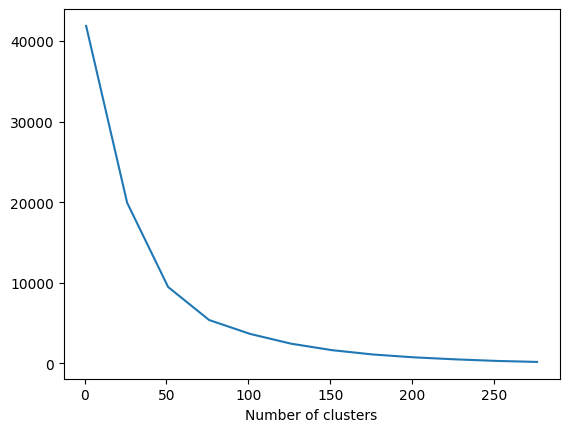

In [156]:
# Let's map the inertia for different number of clusters to find the optimal number of clusters
# We'll plot it to see the elbow
inertia = []
clusters = 300
step = 25
max_iter = 50
n_init = 5
random_state = 42
for k in range(1, clusters, step):
    kmeans = KMeans(
        n_clusters=k,
        max_iter=max_iter,
        n_init=n_init,
        random_state=random_state,
    ).fit(X_lsa)
    # inertia is the sum of squared distances to the closest cluster center
    inertia.append(kmeans.inertia_)
plt.plot(range(1, clusters, step), inertia)
plt.xlabel('Number of clusters')

There appears to be an elbow about 50, so we'll use 50 clusters.

In [157]:
n_clusters = 50# Number of clusters
kmeans = KMeans(        n_clusters=k,
        max_iter=max_iter,
        n_init=n_init,
        random_state=random_state,
    # Your code here, same as parameters above
).fit(X_lsa)

In [158]:
article_cluster_map = {i: cluster for i, cluster in enumerate(kmeans.labels_)}

# Map the clusters back to the original DataFrame
df['title_cluster'] = df['article_id'].map(article_cluster_map)

In [159]:
# Let's check the number of articles in each cluster
np.array(np.unique(kmeans.labels_, return_counts=True)).T

array([[   0, 1810],
       [   1,  183],
       [   2,   95],
       [   3,  213],
       [   4,  218],
       [   5,  931],
       [   6,  136],
       [   7,   93],
       [   8,  796],
       [   9,  740],
       [  10,  639],
       [  11,  581],
       [  12,  152],
       [  13,  671],
       [  14,  647],
       [  15,  170],
       [  16,  937],
       [  17,  692],
       [  18,   64],
       [  19,  189],
       [  20,  618],
       [  21,  253],
       [  22,  352],
       [  23,  158],
       [  24,  206],
       [  25,  171],
       [  26,  150],
       [  27,  643],
       [  28,  250],
       [  29,  215],
       [  30,  614],
       [  31,  427],
       [  32,  131],
       [  33,  574],
       [  34,  473],
       [  35,  457],
       [  36,  495],
       [  37,  157],
       [  38,  533],
       [  39,  372],
       [  40,  440],
       [  41,  442],
       [  42,  371],
       [  43,  345],
       [  44,  347],
       [  45,  435],
       [  46,  433],
       [  47,

In [160]:
def get_similar_articles(article_id, df=df):
    """
    INPUT:
    article_id - (int) an article id
    df - (pandas dataframe) df as defined at the top of the notebook

    OUTPUT:
    article_ids - (list) a list of article ids that are in the same title cluster

    Description:
    Returns a list of the article ids that are in the same title cluster
    """
    title_cluster = df.loc[df['article_id'] == article_id, 'title_cluster'].values[0]


    articles_in_cluster = df[df['title_cluster'] == title_cluster]['article_id'].tolist()


    articles_in_cluster = [id_ for id_ in articles_in_cluster if id_ != article_id]
    return articles_in_cluster

In [161]:
def make_content_recs(article_id, n, df=df):
    """
    INPUT:
    article_id - (int) an article id
    n - (int) the number of recommendations you want similar to the article id
    df - (pandas dataframe) df as defined at the top of the notebook

    OUTPUT:
    n_ranked_similar_articles - (list) a list of article ids that are in the same title cluster ranked
                                by popularity
    n_ranked_article_names - (list) a list of article names associated with the list of article ids

    Description:
    Returns a list of the n most ranked similar articles to a given article_id based on the title
    cluster in df. Rank similar articles using the function get_ranked_article_unique_counts.
    """

    title_cluster = df.loc[df['article_id'] == article_id, 'title_cluster'].values[0]

    articles_in_cluster = df[df['title_cluster'] == title_cluster]['article_id'].tolist()

    articles_in_cluster = [id_ for id_ in articles_in_cluster if id_ != article_id]

    ranked_articles = get_ranked_article_unique_counts(articles_in_cluster,user_item=user_item)

    ranked_similar_articles = [article_id for article_id, _ in ranked_articles if article_id in articles_in_cluster]

    n_ranked_similar_articles = ranked_similar_articles[:n]

    n_ranked_article_names = get_article_names(n_ranked_similar_articles, df)

    return n_ranked_similar_articles, n_ranked_article_names

In [162]:
# Test out your content recommendations given artice_id 25
rec_article_ids, rec_article_titles = make_content_recs(25, 10)
print(rec_article_ids)
print(rec_article_titles)

[1017.0, 600.0, 116.0, 1176.0, 12.0, 59.0, 544.0, 58.0, 751.0]
['timeseries data analysis of iot events by using jupyter notebook', 'access ibm analytics for apache spark from rstudio', 'build a python app on the streaming analytics service', 'build a predictive analytic model', 'the pandas data analysis library', 'practical tutorial on random forest and parameter tuning in r', 'data visualization with ggplot2 cheat sheet', '20405    how to tame the valley — hessian-free hacks fo...\nName: title, dtype: object', 'advancements in the spark community']


In [163]:
# assert len({1025, 593, 349, 821, 464, 29, 1042, 693, 524, 352}.intersection(set(rec_article_ids))) > 0, "Oops! Your the make_content_recs function doesn't work quite how we expect."

`2.` Now that you have put together your content-based recommendation system, use the cell below to write a summary explaining how your content based recommender works.  Do you see any possible improvements that could be made to your function? What other text data would be useful to help make better recommendations besides the article title?

**Write an explanation of your content based recommendation system here.**

> The content-based recommendation system I built works by analyzing the similarity between article titles. To generate recommendations, the system transforms the text of each title into a vector representation and then compares these vectors to identify articles that are most similar to the one the user has already interacted with. In this way, the model is able to suggest content that shares keywords or semantic patterns with previously viewed articles.  

> One possible improvement to this approach would be to use more advanced Natural Language Processing (NLP) techniques, such as TF-IDF weighting or word embeddings (e.g., Word2Vec, GloVe, or BERT). These methods would capture deeper semantic relationships between words, allowing the system to go beyond exact keyword matching and provide more meaningful recommendations.  

> In addition to titles, other types of text data would be highly useful to improve recommendations. For example, incorporating the full article content, abstracts, descriptions, or tags could provide richer information to compare. Metadata such as authors, publication date, or article categories could also add valuable context and diversity to the recommendations. Overall, while the current system works as a baseline, adding more sophisticated text features and richer content would significantly improve its performance.

### <a class="anchor" id="Matrix-Fact">Part V: Matrix Factorization</a>

In this part of the notebook, you will build use matrix factorization to make article recommendations to users.

`1.` You should have already created a **user_item** matrix above in **question 1** of **Part III** above.  This first question here will just require that you run the cells to get things set up for the rest of **Part V** of the notebook.

In [164]:
# quick look at the matrix
user_item.head()

article_id,0.0,2.0,4.0,8.0,9.0,12.0,14.0,15.0,16.0,18.0,...,1434.0,1435.0,1436.0,1437.0,1439.0,1440.0,1441.0,1442.0,1443.0,1444.0
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


`2.` In this situation, you can use Singular Value Decomposition from [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html) on the user-item matrix.  Use the cell to perform SVD.

In [165]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import precision_score, recall_score, accuracy_score
# Using the full number of components which equals the number of columns
svd = TruncatedSVD(n_components=len(user_item.columns), n_iter=5, random_state=42)

u = svd.fit_transform(user_item)
v = svd.components_
s = svd.singular_values_
print('u', u.shape)
print('s', s.shape)
print('vt', v.shape)

u (5149, 714)
s (714,)
vt (714, 714)


`3.` Now for the tricky part, how do we choose the number of latent features to use?  Running the below cell, you can see that as the number of latent features increases, we obtain better metrics when making predictions for the 1 and 0 values in the user-item matrix.  Run the cell below to get an idea of how our metrics improve as we increase the number of latent features.

Text(0.5, 1.0, 'Metrics vs. Number of Latent Features')

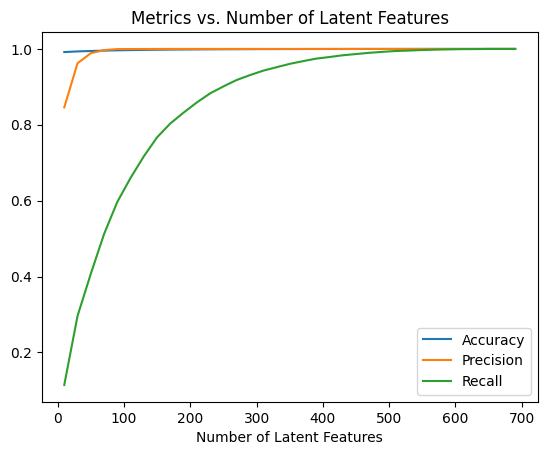

In [166]:
num_latent_feats = np.arange(10, 700+10, 20)
metric_scores = []

for k in num_latent_feats:
    # restructure with k latent features
    u_new, vt_new = u[:, :k], v[:k, :]

    # take dot product
    user_item_est = abs(np.around(np.dot(u_new, vt_new))).astype(int)
    # make sure the values are between 0 and 1
    user_item_est = np.clip(user_item_est, 0, 1)

    # total errors and keep track of them
    acc = accuracy_score(user_item.values.flatten(), user_item_est.flatten())
    precision = precision_score(user_item.values.flatten(), user_item_est.flatten())
    recall = recall_score(user_item.values.flatten(), user_item_est.flatten())
    metric_scores.append([acc, precision, recall])


plt.plot(num_latent_feats, metric_scores, label=['Accuracy', 'Precision', 'Recall'])
plt.legend()
plt.xlabel('Number of Latent Features')
plt.title('Metrics vs. Number of Latent Features')

`4.` From the above, we can't really be sure how many features to use, because simply having a better way to predict the 1's and 0's of the matrix doesn't exactly give us an indication of if we are able to make good recommendations. Given the plot above, what would you pick for the number of latent features and why?

**Provide your response here.**

> when analyzing the graph of performance metrics versus the number of latent features, we can see that accuracy and precision quickly reach near-optimal levels with fewer features and remain stable thereafter. On the other hand, recall starts low but steadily increases as more latent features are added, reaching a plateau around 200 features. Selecting 200 latent features is therefore the most appropriate choice because it represents the point of diminishing returns: recall achieves a high value without further significant improvements beyond this point, while accuracy and precision are already close to 1.0. Choosing a much higher number of latent features would only increase model complexity and computational cost, and potentially introduce overfitting, without providing meaningful gains in performance. In short, 200 latent features offer the best trade-off between performance and efficiency, ensuring strong predictive ability while keeping the model manageable.

`5.` Using 200 latent features and the values of U, S, and V transpose we calculated above, create an article id recommendation function that finds similar article ids to the one provide.

Create a list of 10 recommendations that are similar to article with id 4.  The function should provide these recommendations by finding articles that have the most similar latent features as the provided article.

In [167]:
def get_svd_similar_article_ids(article_id, vt, user_item=user_item, include_similarity=False):
    """
    INPUT:
    article_id - (int) an article id
    vt - (numpy array) vt matrix from SVD
    user_item - (pandas dataframe) matrix of users by articles:
                1's when a user has interacted with an article, 0 otherwise
    include_similarity - (bool) whether to include the similarity in the output

    OUTPUT:
    article_ids - (list) a list of article ids that are in the same title cluster

    Description:
    Returns a list of the article ids similar using SVD factorization
    """
    article_idx = np.where(user_item.columns == article_id)[0][0]

    vt_transposed = vt.T
    cos_sim = cosine_similarity(vt_transposed)

    article_similarities = cos_sim[article_idx]

    similar_articles = np.argsort(article_similarities)[::-1]

    similar_articles = similar_articles[similar_articles != article_idx]

    if include_similarity:
        most_similar_items = [
            [user_item.columns[article], article_similarities[article]]
            for article in similar_articles[:10]
        ]
    else:
        most_similar_items = [
            user_item.columns[article] for article in similar_articles[:10]
        ]
    return most_similar_items

In [168]:
# Create a vt_new matrix with 200 latent features
k = 200
vt_new = v[:k, :]

In [169]:
# What is the article name for article_id 4?
print("Current article:", get_article_names([4], df=df)[0])

Current article: analyze ny restaurant data using spark in dsx


In [170]:
# What are the top 10 most similar articles to article_id 4?
rec_articles = get_svd_similar_article_ids(4, vt_new, user_item=user_item)[:10]
rec_articles

[np.float64(1199.0),
 np.float64(1068.0),
 np.float64(486.0),
 np.float64(1202.0),
 np.float64(176.0),
 np.float64(1120.0),
 np.float64(244.0),
 np.float64(793.0),
 np.float64(58.0),
 np.float64(132.0)]

In [171]:
# What are the top 10 most similar articles to article_id 4?
get_article_names(rec_articles, df=df)

['use spark r to load and analyze data',
 'collecting data science cheat sheets',
 '10 powerful features on watson data platform, no coding necessary',
 'notebooks: a power tool for data scientists',
 'country statistics: crude oil - proved reserves',
 'country statistics: crude oil - exports',
 'top analytics tools in 2016',
 'advancements in the spark community',
 'airbnb data for analytics: paris calendar',
 'airbnb data for analytics: athens reviews']

In [172]:
assert set(rec_articles) == {1199, 1068, 486, 1202, 176, 1120, 244, 793, 58, 132}, "Oops! Your the get_svd_similar_article_ids function doesn't work quite how we expect."
print("That's right!  Great job!")

That's right!  Great job!


`6.` Use the cell below to comment on the results you found in the previous question. Given the circumstances of your results, discuss what you might do to determine if the recommendations you make above are an improvement to how users currently find articles, either by Sections 2, 3, or 4? Add any tradeoffs between each of the methods, and how you could leverage each type for different situations including new users with no history, recently new users with little history, and users with a lot of history.

**Your response here.**

>This project showed how different recommendation approaches can be applied to the same dataset and how each one has its strengths and limitations. Simple rank-based methods are easy to implement but lack personalization. Collaborative filtering and content-based approaches introduce more tailored recommendations, though they require sufficient overlap between users and articles to perform well. Matrix factorization provides a powerful way to capture hidden relationships, but it also highlighted the risk of overfitting when the model complexity is not balanced.

> Overall, the exercise underlined the importance of matching the recommendation strategy to the characteristics of the data and the business context. In a real-world application, combining multiple methods and continuously validating them through experiments such as A/B testing would likely be the most effective path to keep users engaged and improve the system over time.


> ## Conclusions on the Methods Used  

>Throughout the project I realized that each recommendation method has its own strengths and weaknesses, and that the key is to understand in which scenarios they work best. The popularity-based approach (*rank-based*) provided a simple and robust starting point, especially useful for new users with no interaction history. However, I noticed that this method lacks personalization, since it tends to recommend the same items to everyone.  

>With user-based collaborative filtering I achieved more personalization, as it identifies similarities in interaction patterns and recommends articles consumed by users with similar behaviors. Still, I observed that this approach is limited when the data is sparse and can be computationally expensive to scale with large datasets.  

>The content-based approach, although optional in this project, proved to be very valuable to complement the system. It allows recommending even new articles by relying on similarities in features such as titles or descriptions. Its main drawback, as I observed, is that it may generate overly homogeneous recommendations, limiting diversity.  

> Finally, by applying matrix factorization techniques such as SVD, I found a more sophisticated way to uncover latent patterns between users and items. This method showed strong predictive power even in sparse data scenarios, although I also recognized that it requires higher computational cost and is less transparent for business stakeholders. Overall, I learned that combining simple and advanced methods provides flexibility and helps design a more complete recommendation system.  

---

> ## Conclusions on Evaluation in Production  

> During the project I understood that it is not enough to evaluate the model in a development environment; it is crucial to think about how to measure its performance in production. In offline testing, metrics such as *precision@k* and *recall@k* were very useful to assess the quality of the recommendations. I also learned that ranking metrics like MAP and NDCG capture both relevance and item ordering more effectively. When the system predicts explicit ratings, error metrics like RMSE or MAE are also important.  

> However, in a real-world context, it is necessary to go beyond technical metrics and focus on how users interact with the system. Metrics such as *CTR (Click-Through Rate)*, conversion rate, and engagement (measured by time spent on recommended content) provide a more direct reflection of user experience and business impact.  

>I also learned that implementing *A/B testing* is a good practice to compare different versions of the system in production and confirm with data whether a change is truly an improvement. Finally, I reflected on the importance of continuous monitoring, since user behaviors can shift over time and degrade the model’s performance. In conclusion, I realized that a successful recommendation system depends not only on its initial accuracy but also on its ability to adapt and remain relevant in the long term.

<a id='conclusions'></a>
### Extras
Using your workbook, you could now save your recommendations for each user, develop a class to make new predictions and update your results, and make a flask app to deploy your results.  These tasks are beyond what is required for this project.  However, from what you learned in the lessons, you certainly capable of taking these tasks on to improve upon your work here!


## Conclusion

> Congratulations!  You have reached the end of the Recommendation Systems project!

> **Tip**: Once you are satisfied with your work here, check over your report to make sure that it is satisfies all the areas of the [rubric](https://review.udacity.com/#!/rubrics/2322/view). You should also probably remove all of the "Tips" like this one so that the presentation is as polished as possible.


## Directions to Submit

> Before you submit your project, you need to create a .html or .pdf version of this notebook in the workspace here. To do that, run the code cell below. If it worked correctly, you should get a return code of 0, and you should see the generated .html file in the workspace directory (click on the orange Jupyter icon in the upper left).

> Alternatively, you can download this report as .html via the **File** > **Download as** submenu, and then manually upload it into the workspace directory by clicking on the orange Jupyter icon in the upper left, then using the Upload button.

> Once you've done this, you can submit your project by clicking on the "Submit Project" button in the lower right here. This will create and submit a zip file with this .ipynb doc and the .html or .pdf version you created. Congratulations!

In [173]:
from subprocess import call
call(['python', '-m', 'nbconvert', 'Recommendations_with_IBM.ipynb'])

255